# Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Carregar dados

In [2]:
df = pd.read_csv("Train_data.csv")

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


### Pré-processamento dos dados

In [3]:
X_raw = df.drop('class', axis=1)
y_raw = df['class']

cat_cols = ['protocol_type', 'service', 'flag']
X_encoded = pd.get_dummies(X_raw, columns=cat_cols)

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

print(f"Classes: {list(le.classes_)}")
print(f"Número de atributos após encoding: {X_encoded.shape[1]}")

Classes: ['anomaly', 'normal']
Número de atributos após encoding: 118


### Divisão treino e teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Dimensões do Treino: {X_train.shape}")
print(f"Dimensões do Teste: {X_test.shape}")

Dimensões do Treino: (17634, 118)
Dimensões do Teste: (7558, 118)


### Treinamento do Modelo

In [5]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5]
}

print("Busca pelos melhores hiperparâmetros do Random Forest.")
start_time = time.time()

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1
)

grid_search.fit(X_train, y_train)

end_time = time.time()

print(f"Tempo de busca: {end_time - start_time:.2f} segundos")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor Acurácia na Validação Cruzada: {grid_search.best_score_:.4%}")

Busca pelos melhores hiperparâmetros do Random Forest.
Tempo de busca: 54.32 segundos
Melhores parâmetros encontrados: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Melhor Acurácia na Validação Cruzada: 99.7278%


### Avaliação do Modelo

--- Treinamento Final com os Melhores Parâmetros ---
Tempo de inferência (teste): 0.1517 segundos
Acurácia no Teste: 99.7618%

Relatório de Classificação:
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00      3523
      normal       1.00      1.00      1.00      4035

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558



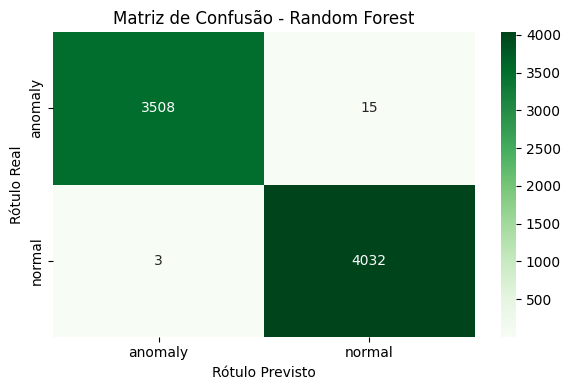

In [6]:
print("--- Treinamento Final com os Melhores Parâmetros ---")
melhor_rf = grid_search.best_estimator_

start_time_test = time.time()
y_pred = melhor_rf.predict(X_test)
end_time_test = time.time()

acc_final = accuracy_score(y_test, y_pred)
print(f"Tempo de inferência (teste): {end_time_test - start_time_test:.4f} segundos")
print(f"Acurácia no Teste: {acc_final:.4%}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.tight_layout()
plt.show()

### Interpretação
Atributos mais relevantes segundo a importância calculada pelo Random Forest.

Top 10 Atributos de Maior Importância no Modelo:
src_bytes                      0.121895
dst_bytes                      0.109475
dst_host_srv_count             0.062014
diff_srv_rate                  0.058815
flag_SF                        0.052574
dst_host_srv_serror_rate       0.049746
count                          0.044177
dst_host_same_srv_rate         0.043062
dst_host_same_src_port_rate    0.041289
dst_host_diff_srv_rate         0.036114
dtype: float64


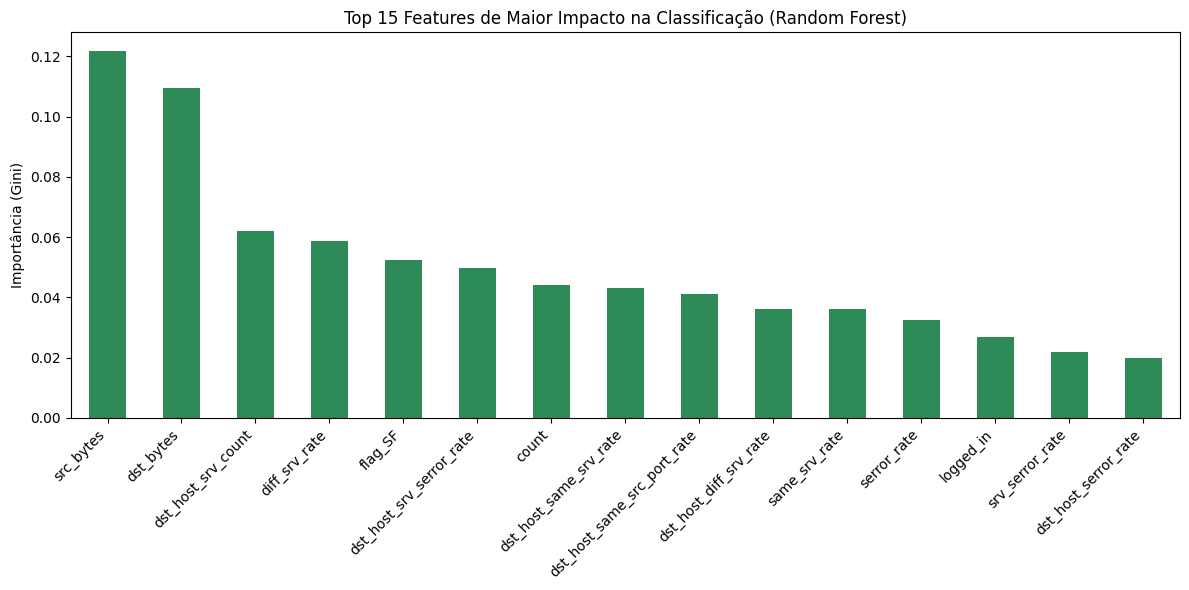

In [7]:
importancias_rf = pd.Series(melhor_rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

print("Top 10 Atributos de Maior Importância no Modelo:")
print(importancias_rf.head(10))

plt.figure(figsize=(12, 6))
importancias_rf.head(15).plot(kind='bar', color='seagreen')
plt.title("Top 15 Features de Maior Impacto na Classificação (Random Forest)")
plt.ylabel("Importância (Gini)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Importância agregada por atributo original

Top 10 Atributos Originais por Importância Agregada:
src_bytes                      0.121895
dst_bytes                      0.109475
flag                           0.075310
dst_host_srv_count             0.062014
diff_srv_rate                  0.058815
service                        0.057502
dst_host_srv_serror_rate       0.049746
count                          0.044177
dst_host_same_srv_rate         0.043062
dst_host_same_src_port_rate    0.041289
dtype: float64


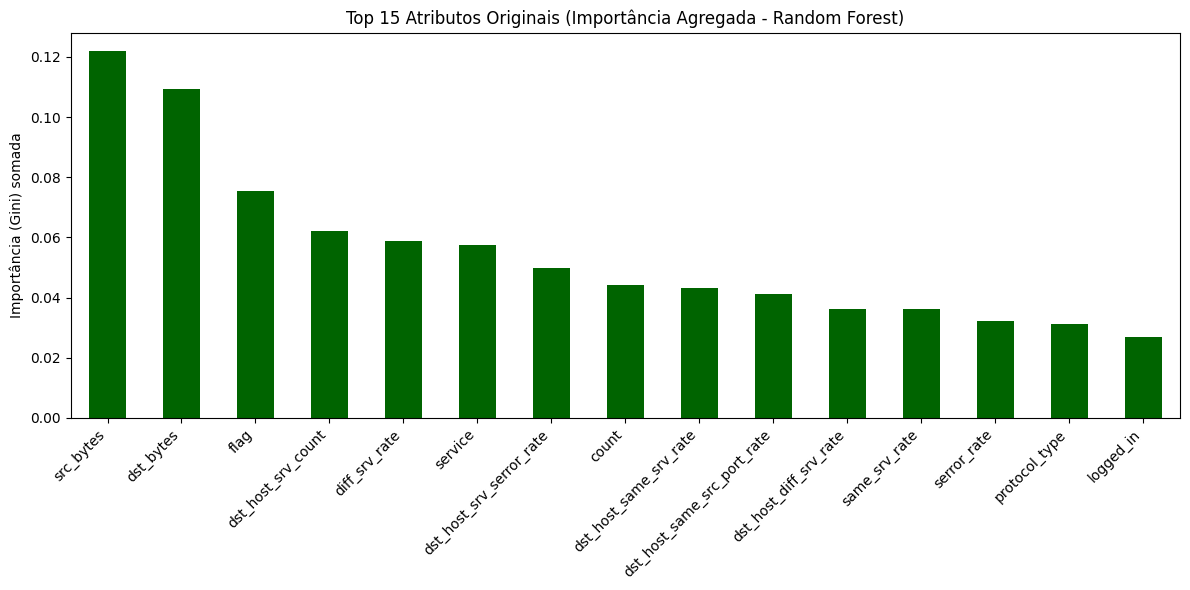

In [8]:
def atributo_original(coluna):
    for prefixo in cat_cols:
        if coluna.startswith(prefixo + '_'):
            return prefixo
    return coluna

importancias_agregadas = (
    importancias_rf
    .groupby(importancias_rf.index.map(atributo_original))
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Atributos Originais por Importância Agregada:")
print(importancias_agregadas.head(10))

plt.figure(figsize=(12, 6))
importancias_agregadas.head(15).plot(kind='bar', color='darkgreen')
plt.title("Top 15 Atributos Originais (Importância Agregada - Random Forest)")
plt.ylabel("Importância (Gini) somada")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Teste de Resiliência

In [9]:
print("--- TESTE DE RESILIÊNCIA: Simulando a perda de 'src_bytes' ---")

coluna_alvo = 'src_bytes'
X_train_resiliente = X_train.drop(columns=[coluna_alvo])
X_test_resiliente = X_test.drop(columns=[coluna_alvo])

print(f"Dimensões APÓS remover a feature:")
print(f"Treino: {X_train_resiliente.shape} | Teste: {X_test_resiliente.shape}\n")

rf_resiliente = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_resiliente.fit(X_train_resiliente, y_train)

y_pred_resiliente = rf_resiliente.predict(X_test_resiliente)
acc_resiliente = accuracy_score(y_test, y_pred_resiliente)

print("--- RESULTADOS DO IMPACTO ---")
print(f"Acurácia Original (Com {coluna_alvo}): {acc_final:.4%}")
print(f"Acurácia Resiliente (Sem {coluna_alvo}): {acc_resiliente:.4%}")
print(f"Queda Absoluta na Acurácia: {(acc_final - acc_resiliente):.4%}")

--- TESTE DE RESILIÊNCIA: Simulando a perda de 'src_bytes' ---
Dimensões APÓS remover a feature:
Treino: (17634, 117) | Teste: (7558, 117)

--- RESULTADOS DO IMPACTO ---
Acurácia Original (Com src_bytes): 99.7618%
Acurácia Resiliente (Sem src_bytes): 99.6825%
Queda Absoluta na Acurácia: 0.0794%
